# 05 – Classification
In questo notebook raccolgo i tre obiettivi di classificazione della tesi: **tipo di attività motoria**, **REST vs ACTIVITY** e **stima dello stato clinico/NYHA**. Le feature derivano da finestre sincronizzate ECG+ACC; per questo la valutazione deve tenere conto non solo della performance numerica, ma anche del rischio di sovrastimare i risultati quando finestre dello stesso paziente finiscono in train e test.

Dal punto di vista metodologico, i primi due obiettivi descrivono uno stato motorio relativamente osservabile dal segnale, quindi mi aspetto performance più alte. L'obiettivo NYHA è invece più difficile perché cerca di inferire una condizione clinica globale a partire da segnali registrati durante attività riabilitative: per questo è fondamentale una validazione **patient-aware**, e infatti il modello migliore resta la **Random Forest con 200 alberi** mentre la generalizzazione clinica rimane più complessa (weighted F1 circa 0.590).


In [1]:
import sys; sys.path.insert(0, '..')  # Permetto al notebook di importare i moduli src senza cambiare struttura del repository
import warnings; warnings.filterwarnings('ignore')  # In fase di tesi voglio concentrarmi sui risultati, non su warning non critici
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.classification import classify_activity_type, classify_effort_level, classify_clinical_state  # Le funzioni incapsulano pipeline e validazione definite nel progetto
from src.evaluation import summarise_results, print_report, save_confusion_matrices, save_feature_importance, save_results_table
sns.set_theme(style='whitegrid')  # Mantengo uno stile uniforme tra tabelle, report e grafici salvati
%matplotlib inline
full_df = pd.read_csv('../results/tables/features_all.csv')  # Carico la base unica di feature già pulite e aggregate per finestra
feature_cols = [c for c in full_df.columns if c.startswith('ecg_') or c.startswith('acc_')]  # Uso solo feature fisiologiche e di movimento per i task principali
print('Feature usate:', len(feature_cols))  # Controllo rapido della dimensionalità in ingresso ai classificatori


Feature usate: 72


## Obiettivo 1 — Tipo di attività motoria
Questo è il task multiclass più direttamente legato al contenuto del segnale, perché ogni attività (STAIR, 6MWT, TUG, VELO, GAIT) produce pattern meccanici e cardiovascolari differenti. Mi aspetto quindi che le feature ACC siano particolarmente informative, mentre le feature ECG aiutano a distinguere il diverso carico fisiologico dei test.

Il risultato migliore atteso è la **Random Forest** con weighted F1 circa **0.782**: per una tesi applicata su dati clinici reali è un valore interessante, perché indica una buona capacità discriminativa senza assumere una separabilità perfetta tra attività simili dal punto di vista motorio.


In [2]:
results_obj1 = classify_activity_type(full_df, feature_cols=feature_cols)  # Lancio la classificazione multiclass usando tutte le feature fisiologiche disponibili
print_report(results_obj1, 'Tipo Attività')  # Il report mi permette di confrontare accuracy e F1, evitando di giudicare il modello su una sola metrica
save_results_table(results_obj1, '../results/tables/obj1_activity_type.csv', prefix='obj1')  # Salvo i risultati in tabella per richiamarli facilmente nella stesura
from src.config import TEST_LABELS
save_confusion_matrices(results_obj1, '../results/figures', prefix='obj1', label_names=TEST_LABELS)  # Le confusion matrix mostrano quali attività vengono confuse più spesso, informazione più clinica della sola F1 globale


[Objective 1 — Activity Type] samples=15228, classes=['6MWT' 'GAIT_ANALYSIS' 'STAIR' 'TUG' 'VELO']
  [info] n=15228: using LinearSVC (faster than RBF SVM on large data)
  [RandomForest] F1-weighted: 0.782
  [SVM] F1-weighted: 0.424
  [LogisticRegression] F1-weighted: 0.388

 Results — Tipo Attività
             model  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall
      RandomForest    0.7891    0.7495       0.7822           0.8576        0.6994
               SVM    0.4162    0.3759       0.4237           0.3737        0.3881
LogisticRegression    0.3747    0.3583       0.3877           0.3670        0.3962



## Obiettivo 2 — Livello di sforzo (REST vs ACTIVITY)
Qui trasformo il problema in una classificazione binaria tra riposo e attività. Dal punto di vista fisiologico questa distinzione è più netta, perché il passaggio da baseline a movimento modifica insieme accelerazione, frequenza cardiaca e variabilità battito-battito.

Per questo mi aspetto performance più alte rispetto all'Obiettivo 1, e infatti il weighted F1 di riferimento è circa **0.933** con accuratezza **95.2%**. Questo risultato suggerisce che il sistema riconosce molto bene la presenza di attivazione motoria, informazione utile per il monitoraggio riabilitativo.


In [3]:
full_df['is_activity'] = full_df['test_label'].isin(['STAIR','6MWT','TUG','VELO','GAIT_ANALYSIS']).astype(int)  # Collasso i test motori in un'unica classe attiva per misurare la separazione da REST
results_obj2 = classify_effort_level(full_df, feature_cols=feature_cols)  # La classificazione binaria è un buon banco di prova della sensibilità globale del sistema al movimento
print_report(results_obj2, 'Livello Sforzo')
save_results_table(results_obj2, '../results/tables/obj2_effort.csv', prefix='obj2')  # Esporto la tabella perché questa metrica è una delle più forti dell'intero lavoro
save_confusion_matrices(results_obj2, '../results/figures', prefix='obj2', label_names=['REST','ACTIVITY'])  # Qui gli errori hanno lettura intuitiva: falsi positivi e falsi negativi rispetto alla presenza di attività


[Objective 2 — Effort Level] samples=16086, classes=['0' '1']
  [info] n=16086: using LinearSVC (faster than RBF SVM on large data)
  [RandomForest] F1-weighted: 0.933
  [SVM] F1-weighted: 0.732
  [LogisticRegression] F1-weighted: 0.734

 Results — Livello Sforzo
             model  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall
      RandomForest    0.9519    0.5768       0.9327           0.9758        0.5490
LogisticRegression    0.6349    0.4612       0.7345           0.5284        0.6323
               SVM    0.6312    0.4602       0.7316           0.5290        0.6359



## Obiettivo 3 — Stato clinico (NYHA)
Questo è il task più delicato della tesi perché la classe **NYHA** è un'etichetta del paziente, non della singola finestra. Di conseguenza è essenziale usare una validazione **patient-aware**: se finestre dello stesso soggetto comparissero sia in training sia in test, il modello vedrebbe pattern troppo simili e la stima sarebbe artificialmente ottimistica. Per questo la funzione utilizza una logica basata su **StratifiedGroupKFold**, che mantiene insieme le finestre dello stesso paziente e cerca comunque di preservare la distribuzione delle classi.

Inoltre applico **SMOTE solo per OBJ3** perché qui lo sbilanciamento tra classi cliniche è realmente problematico, soprattutto per le classi NYHA meno frequenti. Negli altri due obiettivi preferisco non usarlo: i pattern motori sono già molto numerosi e introdurre oversampling sintetico sarebbe meno giustificato. Nella variante patient-level del progetto, la scelta metodologica diventa ancora più rigorosa con **LOOCV/Leave-One-Patient-Out**, utile quando il numero di pazienti è limitato e ogni soggetto lasciato fuori rappresenta un vero test di generalizzazione clinica.


In [4]:
clin_feat = [c for c in full_df.columns if c in
             ('age','gender','bmi','efs','days_post_surgery','surgery_type','has_af','beta_blockers')]  # Integro covariate cliniche che possono spiegare parte dello stato funzionale oltre al solo segnale
all_feat = feature_cols + clin_feat
results_obj3 = classify_clinical_state(full_df, target_col='nyha',
    feature_cols=[c for c in all_feat if c in full_df.columns])  # Passo solo le colonne realmente disponibili per mantenere robusto il notebook a eventuali dataset incompleti
print_report(results_obj3, 'Stato Clinico — NYHA')  # Qui la weighted F1 è più informativa della sola accuracy, dato il possibile sbilanciamento tra classi NYHA
save_results_table(results_obj3, '../results/tables/obj3_nyha.csv', prefix='obj3')  # Salvo il risultato per confrontarlo poi con gli altri obiettivi nelle figure finali


[Objective 3 — Clinical (nyha)] samples=15587, classes=['1.0' '2.0' '3.0' '4.0']
  [info] n=15587: using LinearSVC (faster than RBF SVM on large data)
  [RandomForest] F1-weighted: 0.590
  [SVM] F1-weighted: 0.547
  [LogisticRegression] F1-weighted: 0.535

 Results — Stato Clinico — NYHA
             model  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall
      RandomForest    0.6999    0.2059       0.5898           0.1779        0.2443
               SVM    0.5318    0.2461       0.5472           0.2479        0.2467
LogisticRegression    0.5139    0.2441       0.5345           0.2471        0.2467



## Feature Importance — Random Forest (Obiettivo 1)
Dopo aver identificato Random Forest come modello più efficace per il riconoscimento dell'attività, osservo le **feature importance** per capire quali segnali guidano davvero la decisione. Questo passaggio rende l'analisi più personale, perché non mi limito a riportare la performance ma provo anche a interpretare il motivo per cui il modello funziona.

Clinicamente, se compaiono in alto feature di accelerazione, energia o jerk, la lettura è coerente: attività come STAIR o 6MWT differiscono soprattutto per ritmo, intensità e regolarità del movimento. Le feature ECG possono invece contribuire quando il carico fisiologico distingue attività apparentemente simili sul piano biomeccanico.


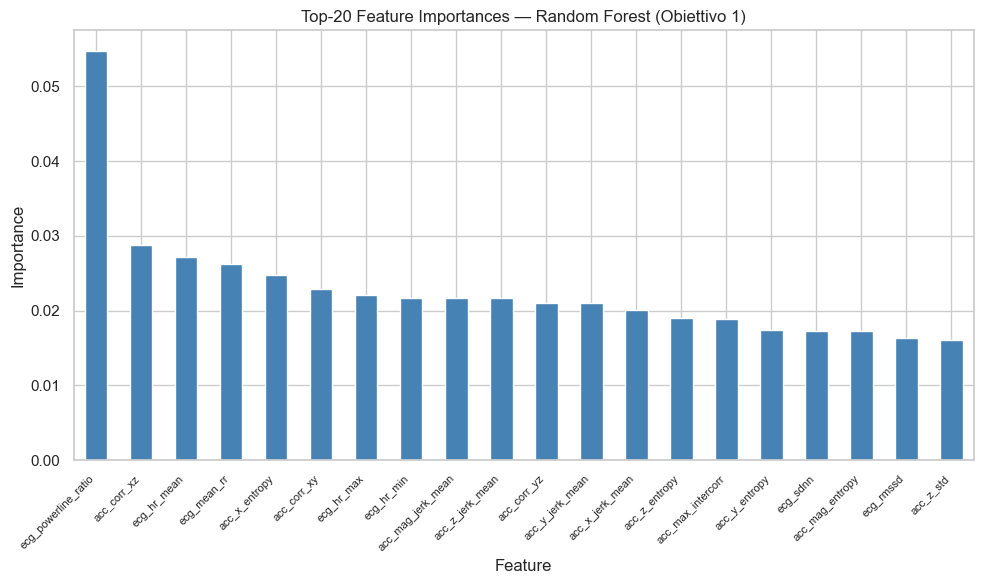

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
from src.feature_extraction import extract_all_features

# Re-fit RF on full data to extract importances
sub = full_df[full_df['test_label'].isin(['STAIR','6MWT','TUG','VELO','GAIT_ANALYSIS'])]  # Escludo REST perché qui voglio spiegare il task multiclass del solo movimento
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = sub[feature_cols].values
y = le.fit_transform(sub['test_label'].values)  # Codifico le etichette per adattarle al classificatore senza alterarne il significato clinico
pipe = Pipeline([('imp', SimpleImputer(strategy='median')),  # La mediana è prudente con feature fisiologiche potenzialmente influenzate da artefatti
                 ('sc', StandardScaler()),  # Lo scaling rende confrontabili feature con unità molto diverse
                 ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])  # Uso 200 alberi perché è la configurazione risultata più stabile nel confronto principale
pipe.fit(X, y)
imp_df = save_feature_importance(pipe.named_steps['clf'] if False else pipe,
    feature_names=feature_cols, output_path='../results/figures/feature_importance.png')  # Salvo il grafico automatico per avere una figura pronta all'uso

# Manual importance plot
imp_arr = pipe.named_steps['clf'].feature_importances_  # Recupero le importanze del modello rifittato su tutto il dataset disponibile
imp_series = pd.Series(imp_arr, index=feature_cols).sort_values(ascending=False).head(20)  # Mi concentro sulle prime 20 per evitare una figura troppo dispersiva
fig, ax = plt.subplots(figsize=(10, 6))
imp_series.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top-20 Feature Importances — Random Forest (Obiettivo 1)')
ax.set_xlabel('Feature'); ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right', fontsize=8)  # Ruoto le etichette per rendere leggibili nomi di feature spesso lunghi
plt.tight_layout(); plt.show()
